In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv('insurance.csv')

In [5]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


***EDA***

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
##Only for the numrical columns, we describe the data (mean, median, mode, count)

In [11]:
df.isnull().sum() # to check how many null values are there in the dataset

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

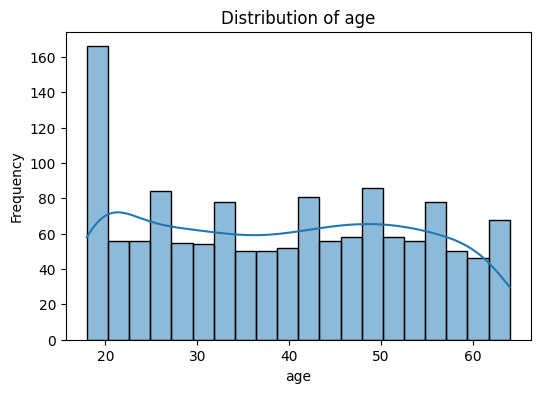

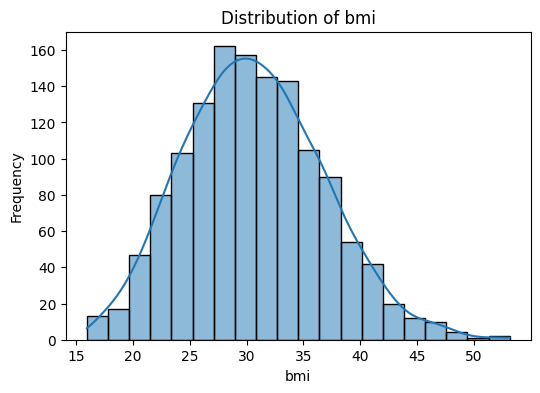

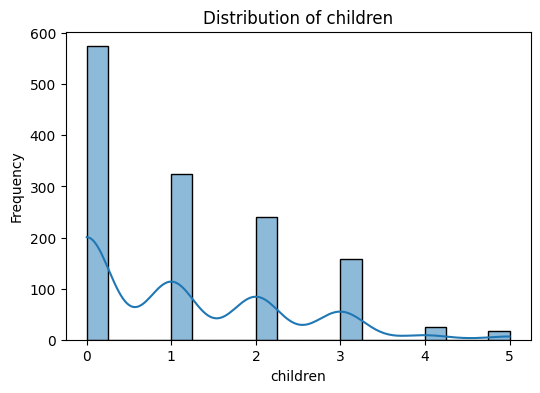

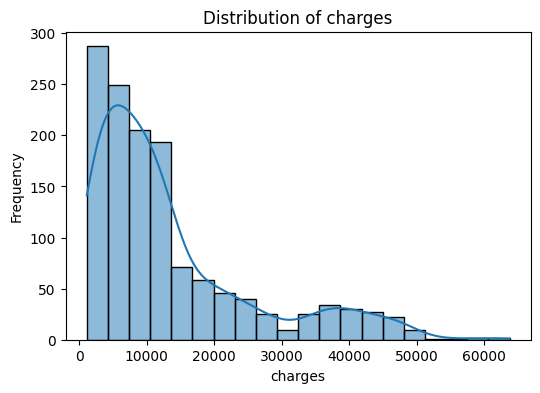

In [12]:
numeric_cols=['age','bmi','children','charges']
for col in numeric_cols:
    plt.figure(figsize=(6,4)  )  #600 * 400 figure size
    sns.histplot(df[col],kde=True,bins=20) # plotting histogram where bins represents the number of bars in the histogram and kde is kernel density estimation which gives us a smooth curve representing the distribution of the data
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

<AxesSubplot:xlabel='children', ylabel='count'>

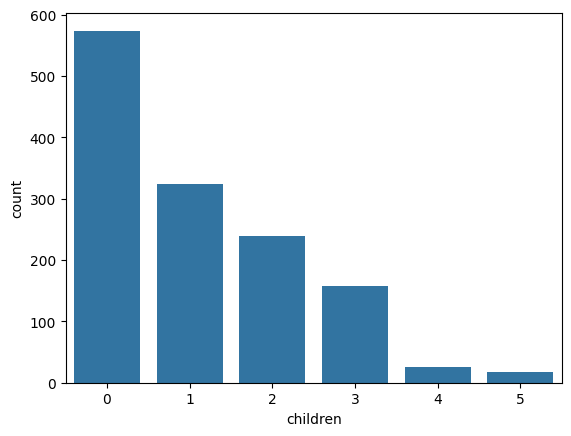

In [13]:
sns.countplot(x=df['children'])

<AxesSubplot:xlabel='sex', ylabel='count'>

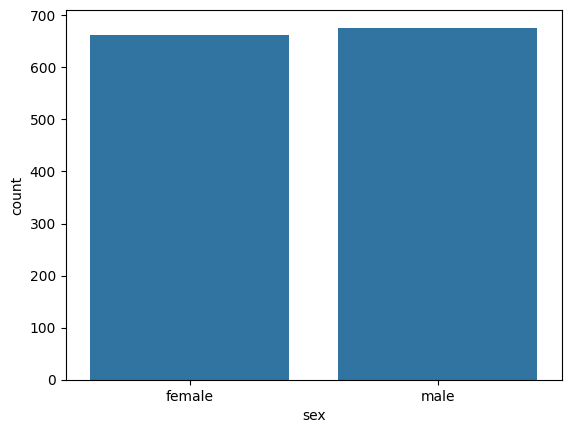

In [14]:
sns.countplot(x=df['sex'])

In [15]:
#almost equal number of male and female data points are there in the dataset

<AxesSubplot:xlabel='smoker', ylabel='count'>

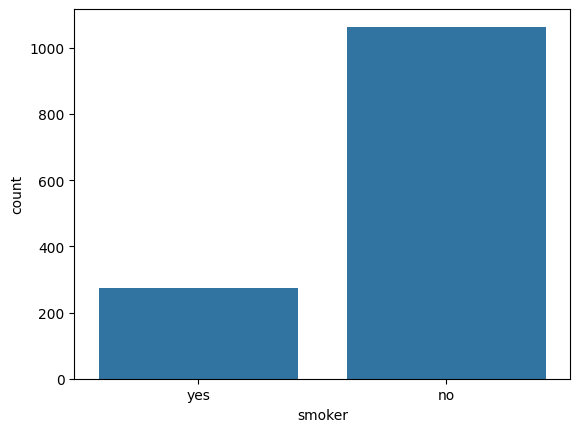

In [16]:
sns.countplot(x=df['smoker'])

<AxesSubplot:xlabel='region', ylabel='count'>

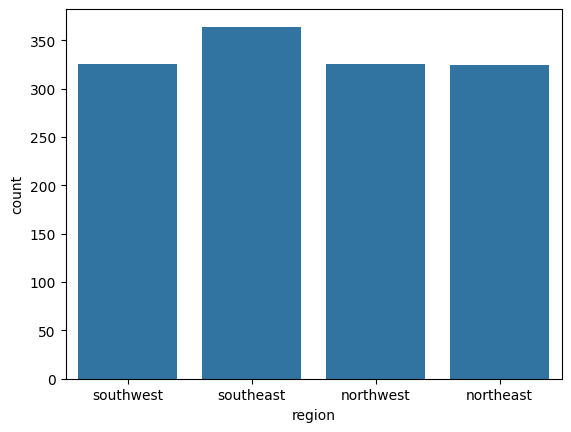

In [17]:
sns.countplot(x=df['region'])

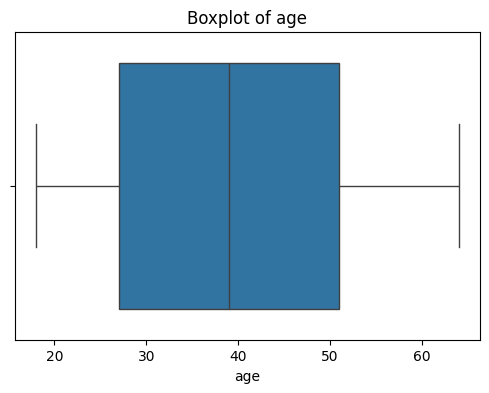

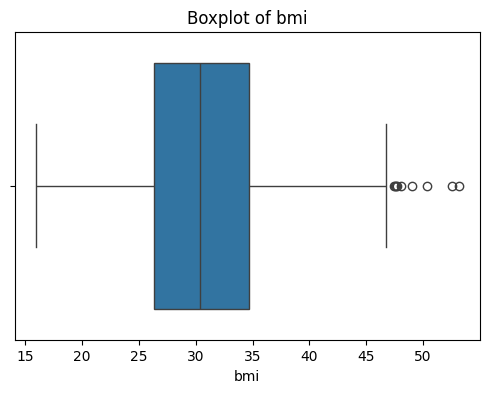

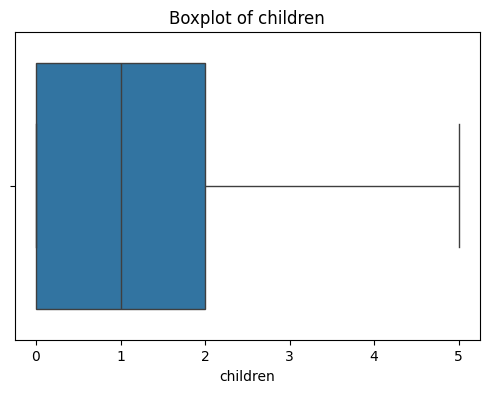

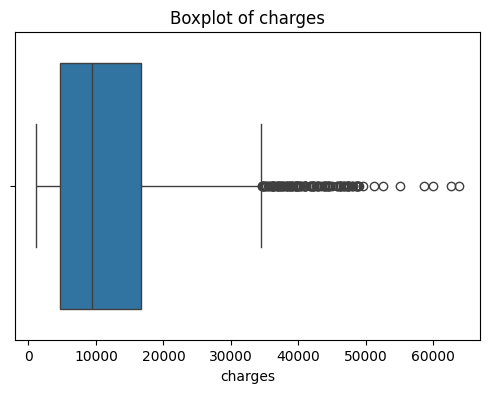

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

<AxesSubplot:>

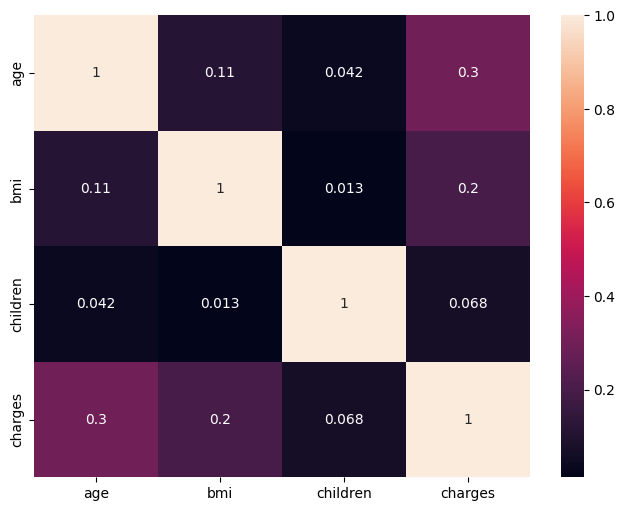

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [20]:
#through this heatmap we can see that there is a string positive relation btw charges and age as well as charges and bmi, however children is least related to every other features 

**Data cleaning and preprocessing** 

In [21]:
df_cleaned=df.copy()

In [22]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
#remove or handle null values if any, here we don't have any
#handle duplicate values in the dataset

In [24]:
df_cleaned.drop_duplicates(inplace=True)  #dupliactes will be removed

In [25]:
df_cleaned.shape

(1337, 7)

In [26]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [27]:
#as such no null values are there in the dataset

In [28]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [29]:
#this returns data types of all the columns in the dataset

In [30]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [31]:
#this shows that value counts of sex feature in the dataset have 2 values only i.e male and female type

In [32]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [33]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [34]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [35]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [36]:
df_cleaned['smoker'].value_counts()
#only 2 categories are there in smoker feature i.e yes and no

smoker
no     1063
yes     274
Name: count, dtype: int64

In [37]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})

In [38]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [39]:
#now 'sex' and 'smoker' features are in numerical format

In [40]:
#changing these column name to something more meaningful

In [41]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker':'is_smoker'
},inplace=True)

In [42]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [43]:
#now we will be encoding region feature using one-hot encoding
#since region feature has 4 categories we will be creating 4 new columns for each category 
# and assigning 1 or 0 to indicate whether the data point belongs to that category or not

In [44]:
df_cleaned['region'].value_counts()
#we will have 4 different categories in the region feature

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [45]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)
#here drop first= true will drop the first category of region feature to avoid multicollinearity
#multicollinearity is a situation where one feature can be predicted from the other features,
#this can cause problems in linear regression models as it can lead to unstable estimates of coefficients and make it difficult to interpret the importance of each feature

In [46]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [47]:
df_cleaned=df_cleaned.astype(int)

In [48]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


**Feature Engineering and Selection**   

In [49]:
#creating new features
#testing , whether new features are useful or not,
#  we will be doing this by checking the correlation of new features with the target variable 'charges' and if the correlation is high then we can say that the new feature is useful for our model
#  otherwise we can drop that feature from our dataset

In [50]:
#for BMI
# if(18.5 - 24.9) then normal weight
# if(25 - 29.9) then overweight
# if(30 or above) then obese

In [51]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,100],
    labels=['underweight','normal','overweight','obese']
    )

In [52]:
df_cleaned.head()
#a new feature as 'bmi_category' is created which categorizes the bmi values into 4 categories i.e underweight, normal, overweight and obese based on the bmi values.

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,normal
4,32,0,28,0,0,3866,1,0,0,overweight


In [53]:
#similar age can be categorized into different age groups like 0-18 as child, 19-35 as adult, 36-60 as middle aged and above 60 as senior citizen

In [54]:
#again converting bmi category into numerical format using one hot encoding

In [55]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True) #drop_first is used to avoid dummy variable trap
#it will drop one category, and will use it as base line 

In [56]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [57]:
#so if all are false -> underweight
#this is done using drop_first = True in get_dummies function,
#  it will drop the first category which is underweight in this case
#and will use it as base line, so if all the other categories are false then it means that the data point belongs to underweight category.

In [58]:
df_cleaned=df_cleaned.astype('int')
#instead of true/false -> we will see 0/1

In [59]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


#Featue Scaling

In [60]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [61]:
#scaling age, bmi, children features using standard scaler,
#  since these features have different scales and we want to bring them to the same scale
#  to improve the performance of our model

In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols]) 

In [64]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [65]:
#feature extraction - selecting importand and relevant features for our model, 
# we will be using correlation matrix to select the features which are highly correlated with the target variable 'charges' 
# and also not highly correlated with each other to avoid multicollinearity.

In [66]:
from scipy.stats import pearsonr
#karls pearson correlation coefficient is a measure of the linear correlation between two variables,
# it ranges from -1 to 1 where -1 indicates a perfect negative correlation, 0 indicates no correlation and 1 indicates a perfect positive correlation.

In [67]:
selected_features=[
    'age','bmi','children','is_female','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_normal','bmi_category_overweight','bmi_category_obese'
]

In [68]:
correlations={
    feature:pearsonr(df_cleaned[feature],df_cleaned['charges'])[0] 
    for feature in selected_features
}
#define correlation btw every feature with the target variable i.e 'charges'
#and storing into a dict where key is the feature name and value is the correlation coefficient

In [69]:
#converting dict to dataframe for better visualization
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature','Pearson Correlation'])

In [70]:
correlation_df.sort_values(by='Pearson Correlation',ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_normal,-0.104042


In [71]:
#this helps in identifying which features are most important for our model and which features can be dropped from the dataset to improve the performance of our model.
#is_smoker being the most important one
#now it is imp to note that: below -0.50 and above 0.50 is considered as strong correlation,
#  between -0.50 and -0.30 or between 0.30 and 0.50 is considered as moderate correlation and
# between -0.30 and 0.30 is considered as weak correlation.

In [72]:
#we can thus remove / drop region_southwest and region_northwest features from the dataset 
# as they have very low correlation with the target variable 'charges' and also with other features.

In [73]:
#now for categorical features we can use chi square test to check 
# the association between the categorical features and the target variable 'charges' 
# and select the features which are significantly associated with the target variable.

In [74]:
cat_features=[
    'is_female','is_smoker','region_northwest',
    'region_southeast','region_southwest',
    'bmi_category_normal','bmi_category_overweight',
    'bmi_category_obese'
]

In [75]:
#applying chi square test
#comparing one category with another cateogory
#but here target variable is continuoius i.e numerical
#thus we will create bins(ranges) of charges variable to convert it into categorical variable and 
# then apply chi square test to check the association between the categorical features
# and the target variable 'charges'

In [76]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha=0.05 #significance level
df_cleaned['charges_bins']=pd.qcut(
    df_cleaned['charges'],q=4,labels=False)
chi2_results={}
for feature in cat_features:
    contingency_table=pd.crosstab(df_cleaned[feature],df_cleaned['charges_bins'])
    chi2,p_value,_,_=chi2_contingency(contingency_table)
    decision='Reject Null Hypothesis(keep feature)' if p_value < alpha else 'Fail to Reject Null Hypothesis(drop feature)'
    chi2_results[feature]={
        'Chi2 Statistic':chi2,
        'P-value':p_value,
        'Decision':decision
    }

In [77]:
#dataframe from dictionary 
chi2_results_df=pd.DataFrame(chi2_results).T
chi2_results_df.sort_values(by='P-value')

,Chi2 Statistic,P-value,Decision
is_smoker,848.219178,0.0,Reject Null Hypothesis(keep feature)
region_southeast,15.998167,0.001135,Reject Null Hypothesis(keep feature)
is_female,10.258784,0.01649,Reject Null Hypothesis(keep feature)
bmi_category_obese,8.515711,0.036473,Reject Null Hypothesis(keep feature)
region_southwest,5.091893,0.165191,Fail to Reject Null Hypothesis(drop feature)
bmi_category_overweight,4.25149,0.235557,Fail to Reject Null Hypothesis(drop feature)
bmi_category_normal,3.708088,0.29476,Fail to Reject Null Hypothesis(drop feature)
region_northwest,1.13424,0.768815,Fail to Reject Null Hypothesis(drop feature)


In [78]:
#thus dropping features such as region_northwest, region_southwest, bmi_category_normal, bmi_category_overweight as they have high p-value and thus are not significantly associated with the target variable 'charges'.
final_df=df_cleaned[['age','bmi','children','is_female','is_smoker','region_southeast','bmi_category_obese','charges']]

In [79]:
final_df
#final dataset after feature selection
#this will be used for model training and testing
#Though hyperparameter tuning can also be done to select the best parameters for our model to improve its performance,
#  but here we will be doing feature selection only.

,age,bmi,children,is_female,is_smoker,region_southeast,bmi_category_obese,charges
0,-1.440418,-0.517949,-0.909234,1,1,0,0,16884
1,-1.511647,0.462463,-0.079442,0,0,1,1,1725
2,-0.799350,0.462463,1.580143,0,0,1,1,4449
3,-0.443201,-1.334960,-0.909234,0,0,0,0,21984
4,-0.514431,-0.354547,-0.909234,0,0,0,0,3866
...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,0,1,10600
1334,-1.511647,0.135659,-0.909234,1,0,0,1,2205
1335,-1.511647,0.952670,-0.909234,1,0,1,1,1629
1336,-1.297958,-0.844753,-0.909234,1,0,0,0,2007


In [80]:
df #actual dataset given, 
#before any cleaning or preprocessing steps, this is the original dataset


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [81]:
#remove/handle null values (if any)
#handle duplicate values in the dataset
#Only Numerical feature
#Encoding (categorical -> numerical) has to be done (either one-hot or label encoding)
#Scaling -> to bring all the features to the same scale 
#feature engineering -> creating new features from existing ones


In [83]:
from sklearn.model_selection import train_test_split

In [84]:
x=final_df.drop('charges',axis=1) #features
#since x is the dataframe which contains all the features(input) except the target variable 'charges'

y=final_df['charges'] #target variable only 

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#we have splitted x dataframe into training and testing sets, where test size is 20% of the total dataset and random state is set to 42 for reproducibility.
#similarly for y dataframe 
#test_size = 20% , means that 20% of the data will be used for testing 
#and 80% of the data will be used for training the model.


In [86]:
from sklearn.linear_model import LinearRegression 

In [88]:
#creating model
model=LinearRegression()
model.fit(x_train,y_train)
 #fitting the model on the training data, where x_train is the input features and y_train is the target variable.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#Now we will be evaluating the model using R-squared and Adjusted R-squared metrics
#  to check how well our model is performing on the test data.

In [ ]:
y_pred=model.predict(x_test) #now we will be predicting the target variable 'charges' for the test data using the trained model and storing the predicted values in y_pred
y_pred #predicting values 

array([ 7856.41808069,  5379.07145062, 14613.47489419, 32465.93193508,
        8955.35729283, 13336.43605749, 30199.07309038,  1403.40503994,
       11196.90873514, 10018.65838301, 10818.71629044, 32144.43533014,
       31550.26059902, 16230.55597963, 10285.99989714,  8488.6608457 ,
        5487.64476113, 32465.09672212,  3304.46601962,  3877.00422671,
        4760.01023433, 28796.29743032, 13870.98195763, 29541.88243902,
       31520.15678042,  6344.44675222, 35026.69683204, 37880.73853364,
       12490.06211178, 14238.95332785,  7573.09915473, 13049.08020135,
         516.21534048, 11339.74207305, 37584.28749479, 13356.84393437,
        3706.96614326,  4537.12786929, 31481.80485676,  8009.55465514,
        6075.79442888, 30404.81913857, 35276.56346051, 13099.59189682,
        7977.69705664,  2987.00634487,  5174.11237148,  7620.54073087,
        3522.89053725, 10388.99625751,  7820.00530896, 10505.68054495,
       30331.09138384,  4687.62077185, 11676.0149257 , 11446.77536361,
      

In [92]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int32

In [93]:
#Model Evaluation (or Performance Metrics)
from sklearn.metrics import r2_score


In [98]:
r2=r2_score(y_test,y_pred)
r2
n=x_test.shape[0]  #no of rows -length of test data
p=x_test.shape[1]  # no of columns
adj_r2=1-(1-r2)*(n-1)/(n-p-1)
adj_r2

0.7987962362937232

In [ ]:
#Our model has given 80% R-squared value which means that our model is able to explain 80% of the variance in the target variable 'charges' using the features we have selected for our model.
#Getting 79.89% adjusted r-squared value which is also a good value and indicates that our model is performing well on the test data.
